In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/raw/weather_data.csv")

In [3]:
df.head()


,date,avg_temperature,humidity,avg_wind_speed,rain_or_not,cloud_cover,pressure
0,2023-01-01,23.745401,46.140905,7.845981,Rain,20.851051,992.965681
1,2023-01-02,30.030503,59.876587,5.382457,Rain,93.059521,1037.273025
2,2023-01-03,28.365224,51.464618,13.158008,Rain,11.636640,1034.193357
3,2023-01-04,27.550929,53.103799,5.886677,Rain,81.744971,968.610142
4,2023-01-05,23.639303,57.826186,12.248992,Rain,38.062329,1030.264331


In [4]:
df.columns

Index(['date', 'avg_temperature', 'humidity', 'avg_wind_speed', 'rain_or_not',
       'cloud_cover', 'pressure'],
      dtype='str')

In [5]:
df.info

<bound method DataFrame.info of            date  avg_temperature   humidity  avg_wind_speed rain_or_not  \
0    2023-01-01        23.745401  46.140905        7.845981        Rain   
1    2023-01-02        30.030503  59.876587        5.382457        Rain   
2    2023-01-03        28.365224  51.464618       13.158008        Rain   
3    2023-01-04        27.550929  53.103799        5.886677        Rain   
4    2023-01-05        23.639303  57.826186       12.248992        Rain   
..          ...              ...        ...             ...         ...   
306  2023-11-03        22.072834  37.756910        4.729355     No Rain   
307  2023-11-04        19.645885  42.190604        8.092369     No Rain   
308  2023-11-05        23.884496  36.205508       11.860847        Rain   
309  2023-11-06        18.168418  34.785000        4.781288     No Rain   
310  2023-11-07        19.389714  37.717416        9.388371     No Rain   

     cloud_cover     pressure  
0      20.851051   992.965681  
1  

In [6]:
columns = df.columns

for col in columns:

    print(f"{col} column contain this much of missing rows :=  {df[col].isna().sum()}")

date column contain this much of missing rows :=  0
avg_temperature column contain this much of missing rows :=  15
humidity column contain this much of missing rows :=  15
avg_wind_speed column contain this much of missing rows :=  15
rain_or_not column contain this much of missing rows :=  0
cloud_cover column contain this much of missing rows :=  15
pressure column contain this much of missing rows :=  0


In [7]:
df.date.duplicated().sum()

np.int64(0)

In [8]:
df["rain_or_not"].unique()

<StringArray>
['Rain', 'No Rain']
Length: 2, dtype: str

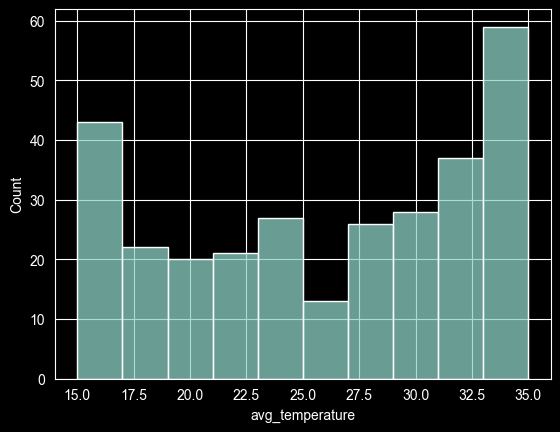

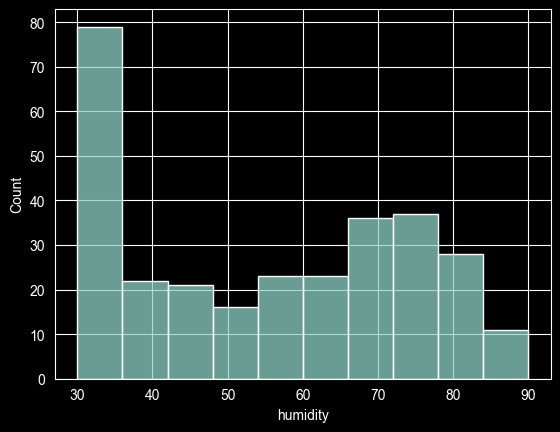

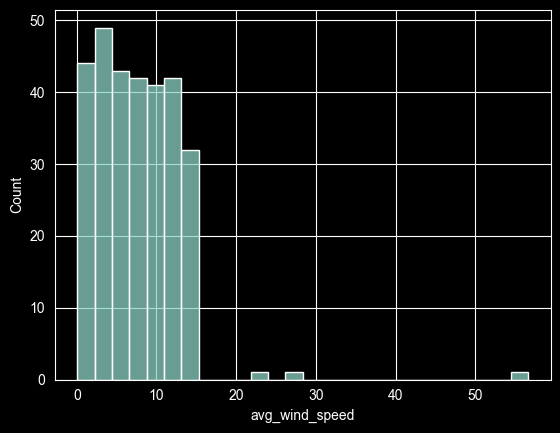

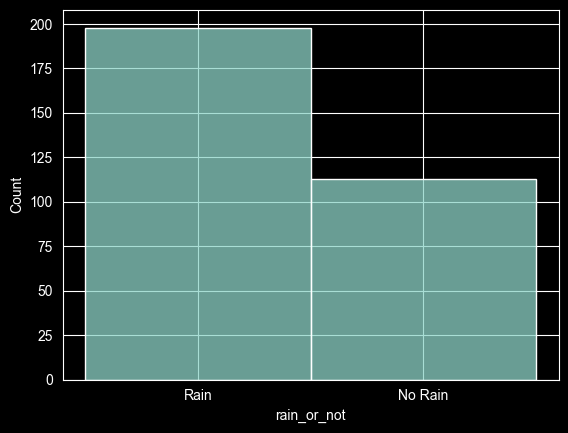

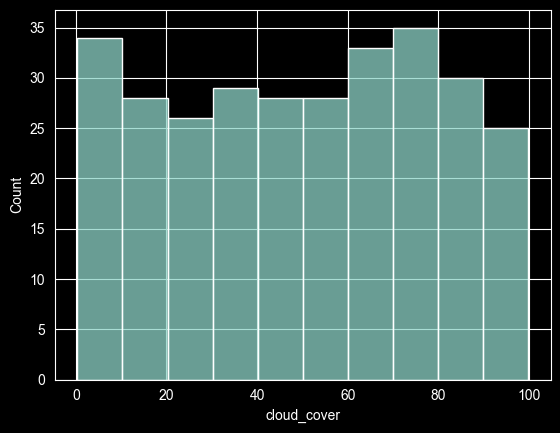

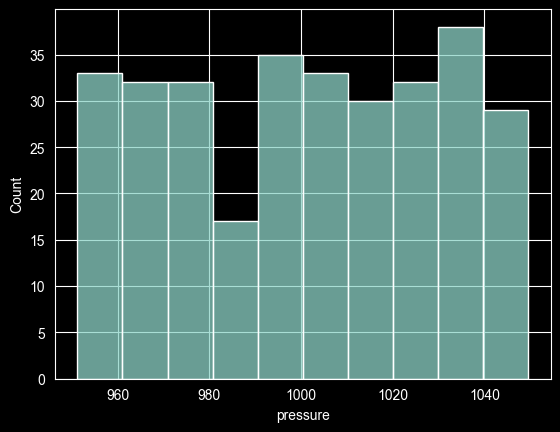

In [9]:

for col in columns:
    if col == "date":
        continue
    plt.figure()
    sns.histplot(df[col])

In [10]:
for col in columns:
    if col == "date":
        continue

    # Correctly identifies numeric columns regardless of pandas version
    if pd.api.types.is_numeric_dtype(df[col]):

        if col == "avg_wind_speed":
            df[col] = df[col].fillna(df[col].median())  # assign back
        else:
            df[col] = df[col].fillna(df[col].mean())    # assign back

In [11]:
columns = df.columns

for col in columns:

    print(f"{col} column contain this much of missing rows :=  {df[col].isna().sum()}")

date column contain this much of missing rows :=  0
avg_temperature column contain this much of missing rows :=  0
humidity column contain this much of missing rows :=  0
avg_wind_speed column contain this much of missing rows :=  0
rain_or_not column contain this much of missing rows :=  0
cloud_cover column contain this much of missing rows :=  0
pressure column contain this much of missing rows :=  0


In [12]:
df.dtypes


date                   str
avg_temperature    float64
humidity           float64
avg_wind_speed     float64
rain_or_not            str
cloud_cover        float64
pressure           float64
dtype: object

In [13]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [14]:
df["rain_or_not"] = df["rain_or_not"].astype(str).str.strip().str.lower()
print(df["rain_or_not"].unique())

df["rain_or_not"] = df.rain_or_not.map({
    "rain":1,
    "no rain":0,
    "not rain":0,
})


<StringArray>
['rain', 'no rain']
Length: 2, dtype: str


In [15]:
print(df["rain_or_not"].unique())
print(df["rain_or_not"].isna().sum())
print(df.info())
print(df.isna().sum())

[1 0]
0
<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             311 non-null    datetime64[us]
 1   avg_temperature  311 non-null    float64       
 2   humidity         311 non-null    float64       
 3   avg_wind_speed   311 non-null    float64       
 4   rain_or_not      311 non-null    int64         
 5   cloud_cover      311 non-null    float64       
 6   pressure         311 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 17.1 KB
None
date               0
avg_temperature    0
humidity           0
avg_wind_speed     0
rain_or_not        0
cloud_cover        0
pressure           0
dtype: int64


In [16]:
df.head(10)

,date,avg_temperature,humidity,avg_wind_speed,rain_or_not,cloud_cover,pressure
0,2023-01-01,23.745401,46.140905,7.845981,1,20.851051,992.965681
1,2023-01-02,30.030503,59.876587,5.382457,1,93.059521,1037.273025
2,2023-01-03,28.365224,51.464618,13.158008,1,11.636640,1034.193357
3,2023-01-04,27.550929,53.103799,5.886677,1,81.744971,968.610142
4,2023-01-05,23.639303,57.826186,12.248992,1,38.062329,1030.264331
5,2023-01-06,24.148136,49.703435,6.587024,1,87.797432,995.818689
6,2023-01-07,23.671006,63.997418,5.654166,1,86.805669,998.296887
7,2023-01-08,32.245441,67.083073,6.940197,1,80.592540,963.347997
8,2023-01-09,30.078517,64.088581,4.520668,1,79.003044,958.060151
9,2023-01-10,31.620631,71.876470,11.214141,1,30.467914,1022.793931


In [17]:
df["rain_or_not"].value_counts()


rain_or_not
1    198
0    113
Name: count, dtype: int64

In [18]:
# Final sanity checks
print("Missing values:\n", df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nTarget distribution:\n", df["rain_or_not"].value_counts())
print("\nData types:\n", df.dtypes)

Missing values:
 date               0
avg_temperature    0
humidity           0
avg_wind_speed     0
rain_or_not        0
cloud_cover        0
pressure           0
dtype: int64

Duplicates: 0

Target distribution:
 rain_or_not
1    198
0    113
Name: count, dtype: int64

Data types:
 date               datetime64[us]
avg_temperature           float64
humidity                  float64
avg_wind_speed            float64
rain_or_not                 int64
cloud_cover               float64
pressure                  float64
dtype: object


In [19]:
Q1 = df["avg_wind_speed"].quantile(0.25)
Q3 = df["avg_wind_speed"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["avg_wind_speed"] = np.where(df["avg_wind_speed"] > upper, upper,
                               np.where(df["avg_wind_speed"] < lower, lower,
                                        df["avg_wind_speed"]))

In [20]:


df.to_csv("../data/processed/cleaned_weather_data.csv", index=False)
